In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
import h5py
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from tqdm.notebook import tqdm
from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

from scipy.signal import find_peaks
import statsmodels.api as sm

import seaborn as sns
sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### Part 1: ALL-OR-NONE + CODES BACKGROUND

In [3]:
patch_c14 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c14patch_filt.npy'
patch_fs_c14 = 50023.8986874656
#get patch data 
patch_filt_c14 = np.load(patch_c14)
patch_c14_one_ms = float(patch_fs_c14  / 1000)
patch_times_c14 = np.arange(0, np.shape(patch_filt_c14 )[0]) / patch_c14_one_ms # in ms instead of sec

In [4]:
#flip sign of patch filt
patch_filt_c14 = -patch_filt_c14

#### Example "raw" spike data - sp1-rh c14

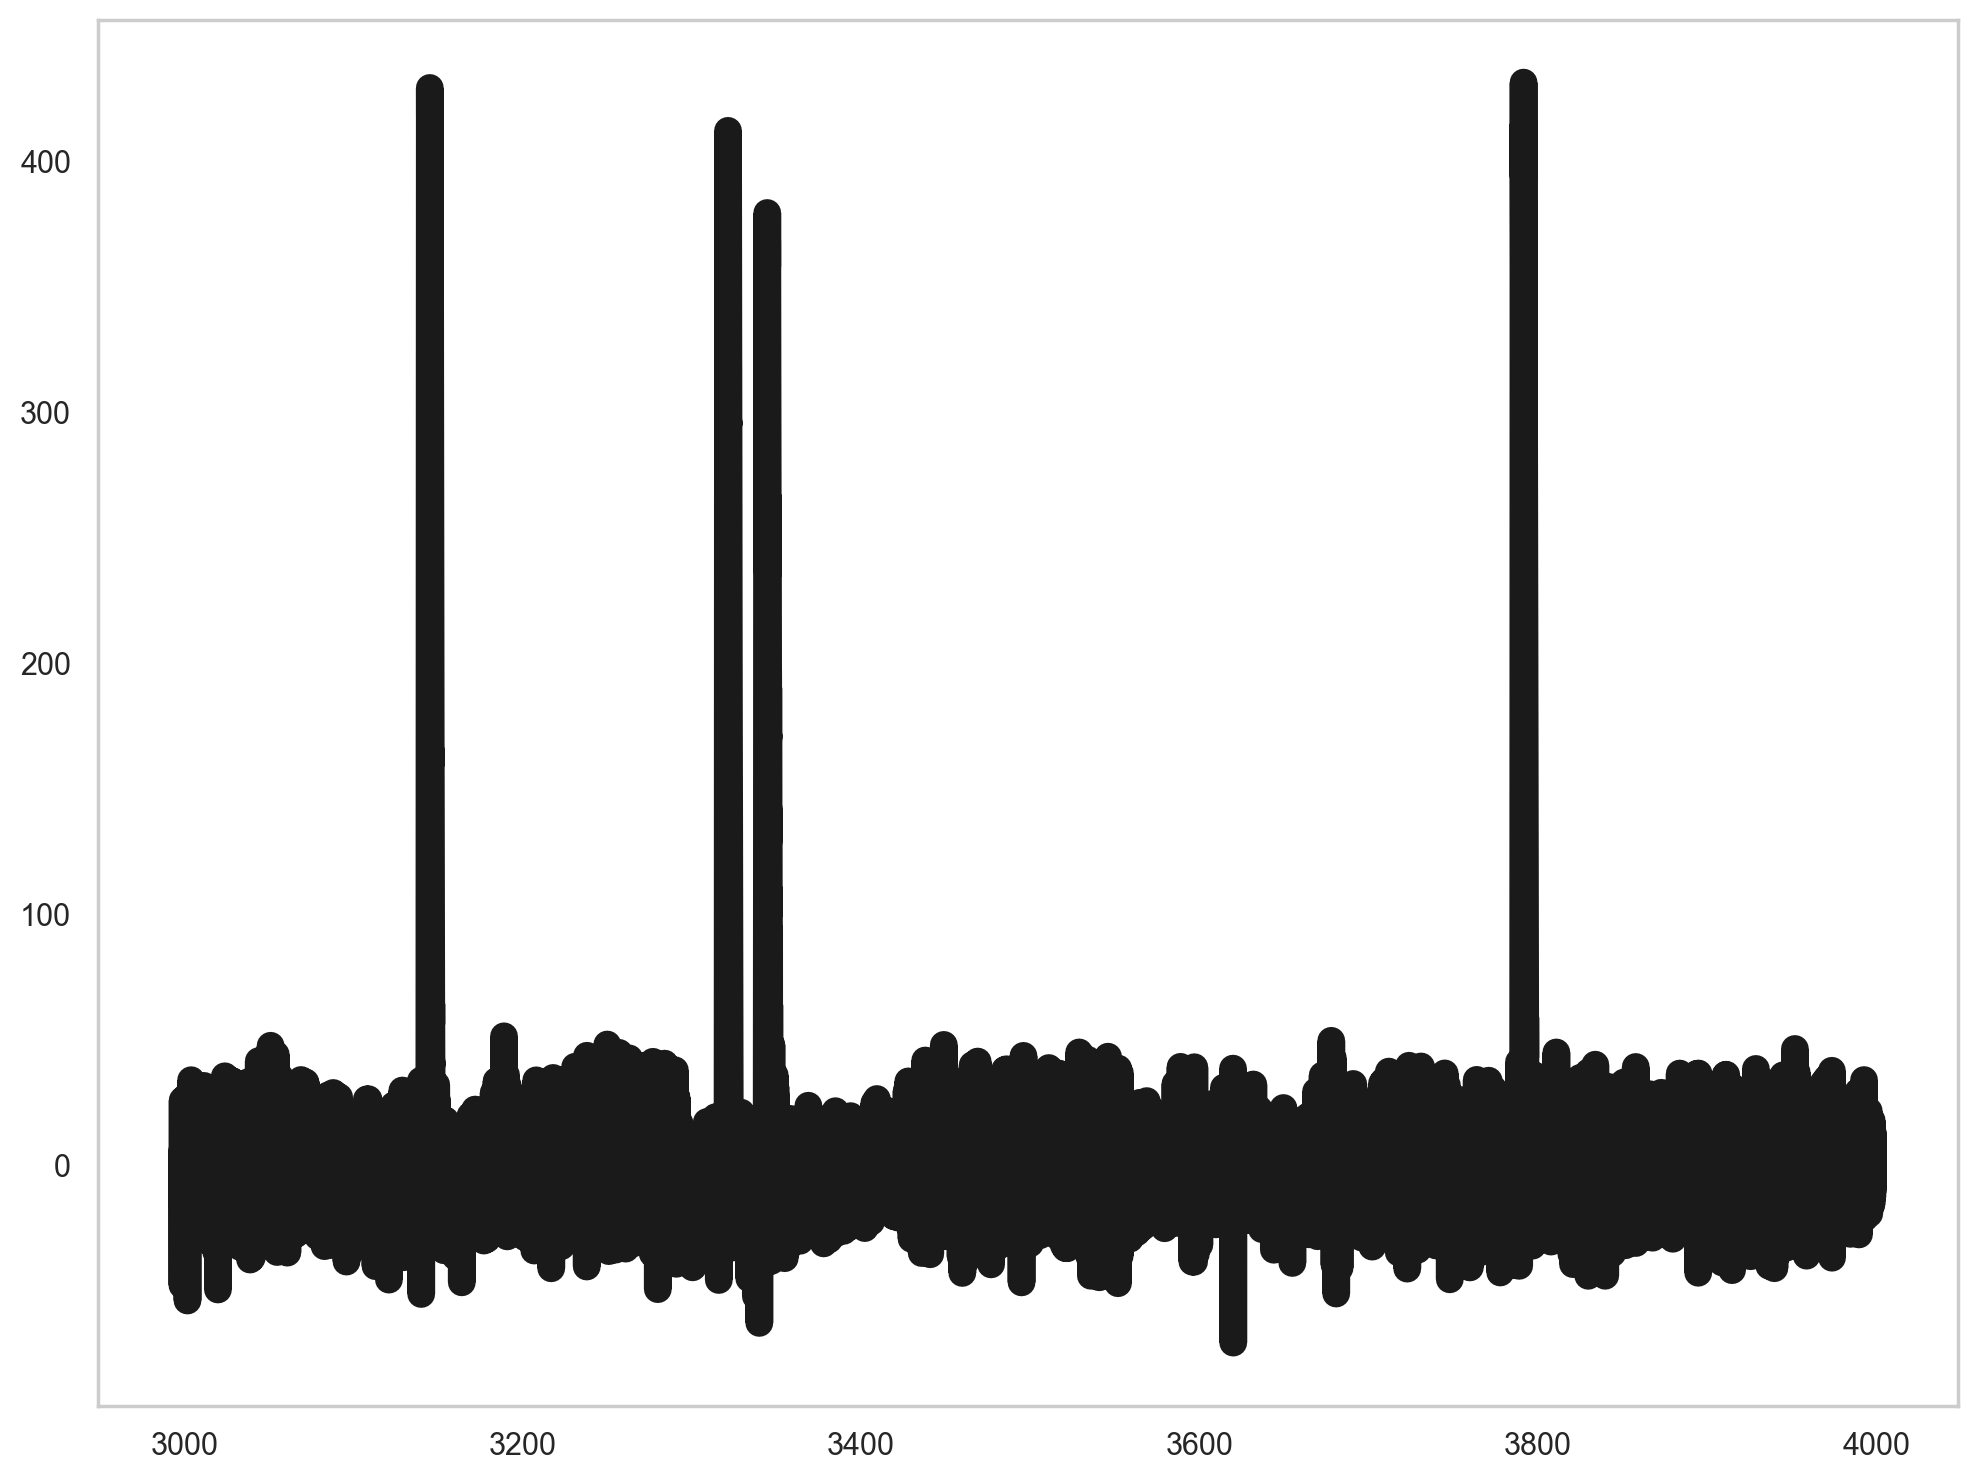

In [5]:
plt.plot(patch_times_c14[150000:200000], patch_filt_c14[150000:200000], color = 'k', linewidth=10)

#### Binarized version 

In [6]:
# Define a threshold, e.g., everything above 100 becomes 1, everything else 0
threshold = 100
binarized_data = np.where(patch_filt_c14[150000:200000] > threshold, 1, 0)
all_binarized_data = np.where(patch_filt_c14 > threshold, 1, 0)

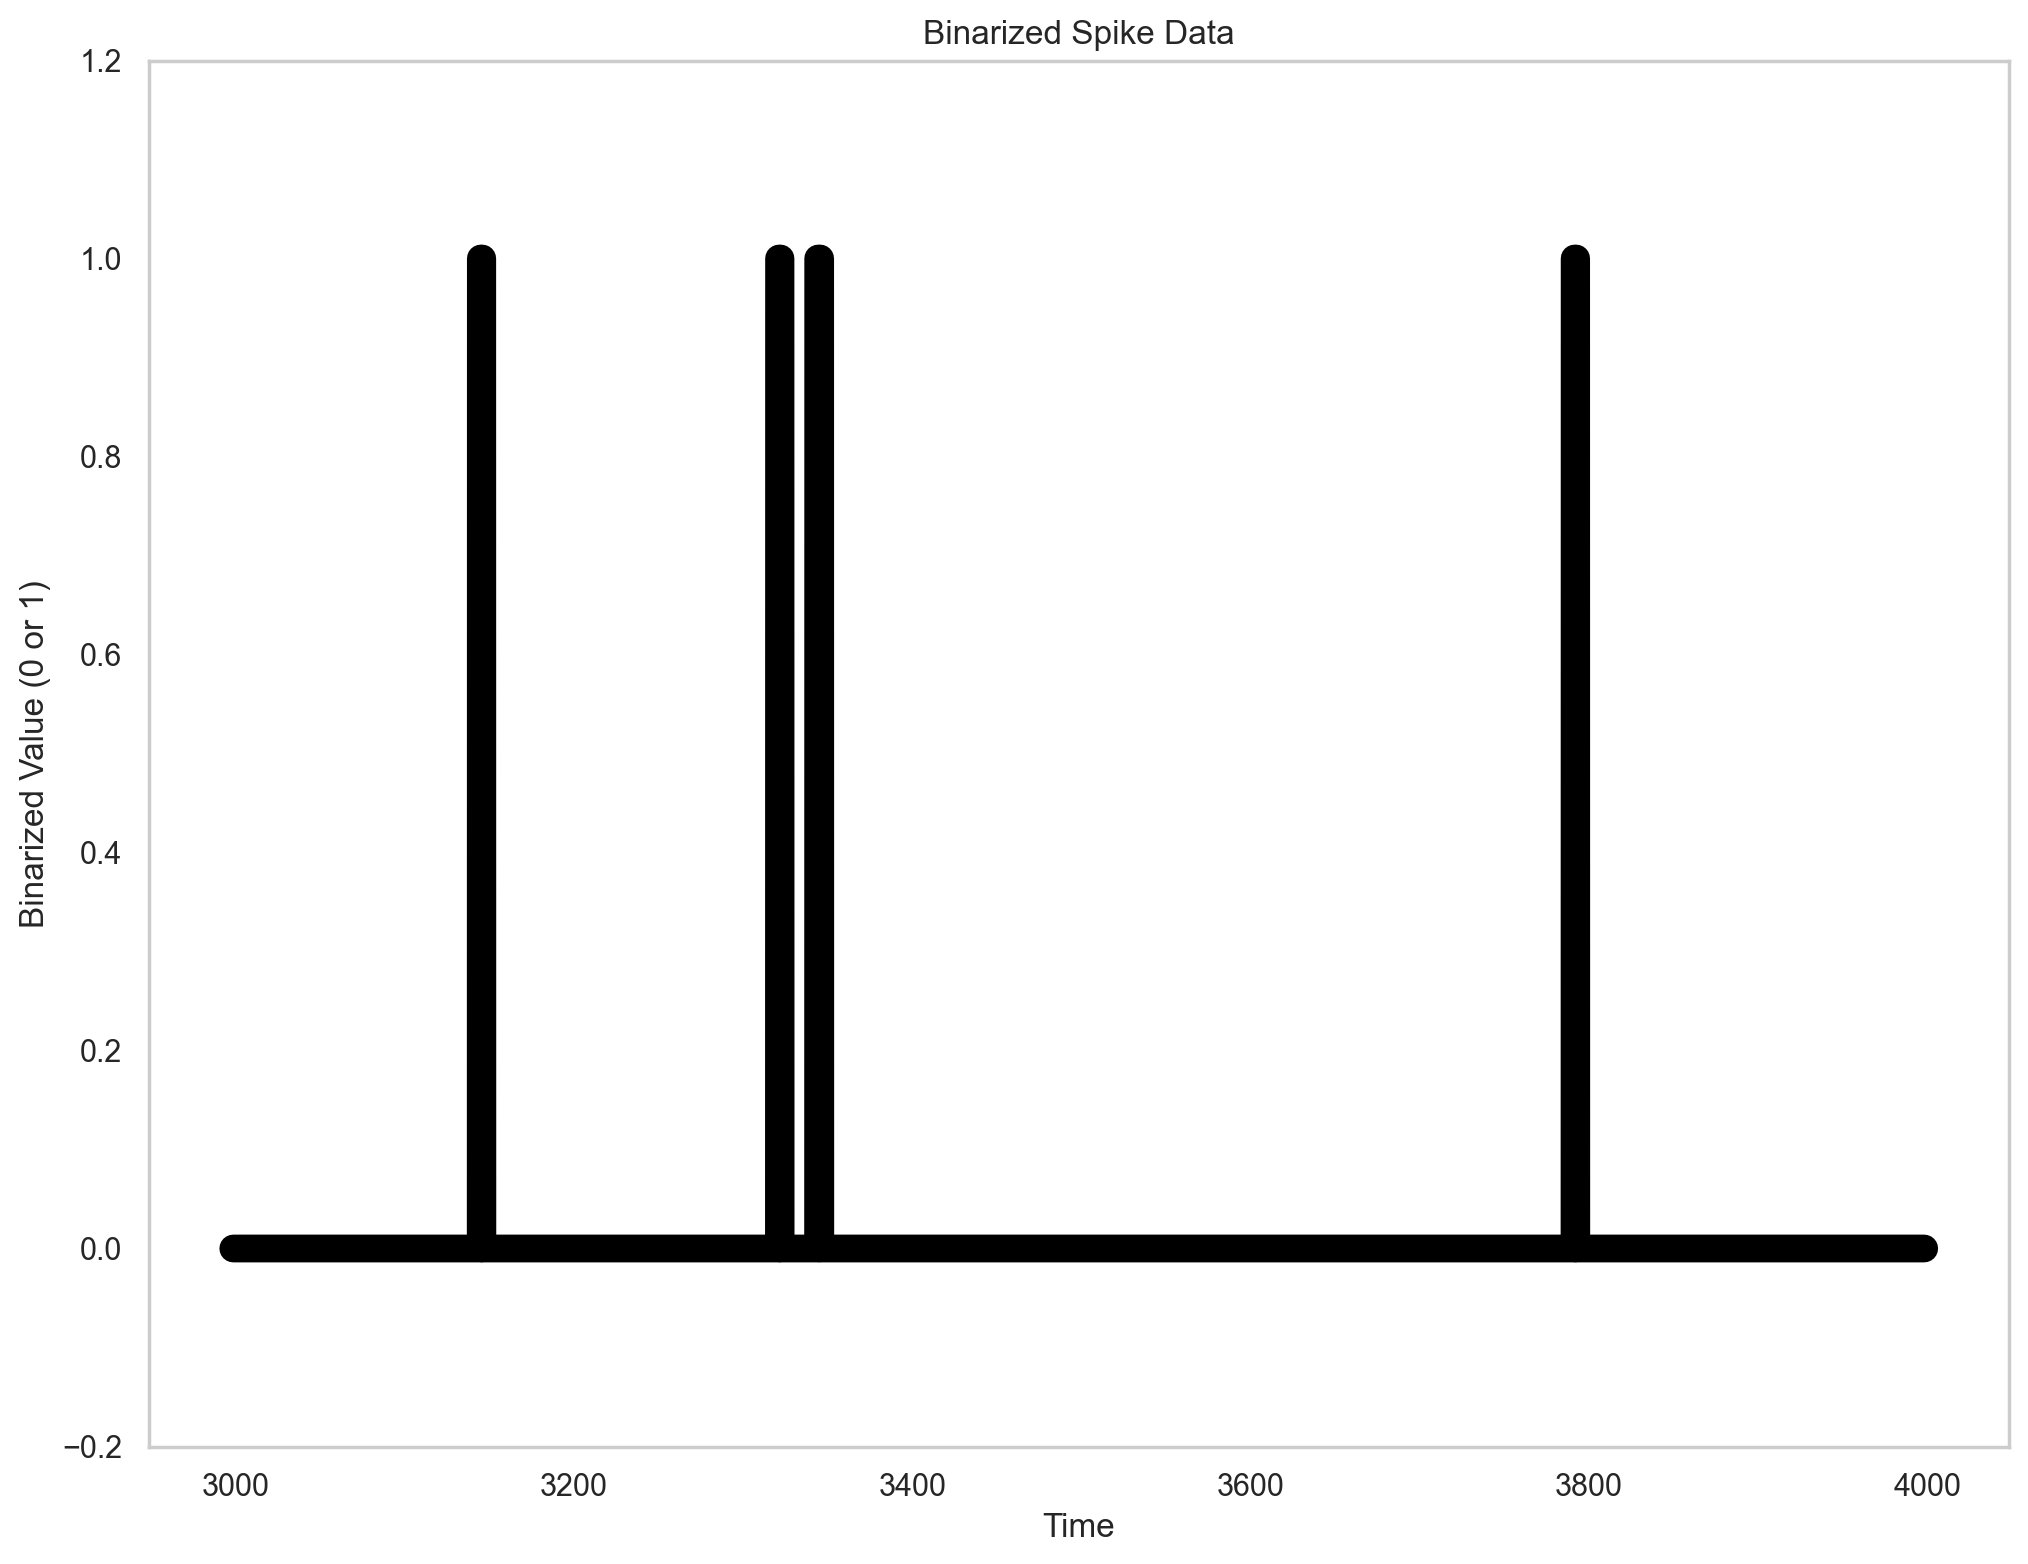

In [7]:
# Plot the binarized data

plt.plot(patch_times_c14[150000:200000], binarized_data, color='black', linewidth=10)
plt.title('Binarized Spike Data')
plt.xlabel('Time')
plt.ylabel('Binarized Value (0 or 1)')
plt.ylim(-0.2, 1.2)  # Keep the y-axis limits between -0.2 and 1.2 for clarity

plt.show()

#### Rate code figure 

In [8]:
# Define your bin size (in time units, e.g., ms)
bin_size = 150000 # For example, 50 ms bins

# Calculate the number of bins
num_bins = int(np.ceil(len(patch_times_c14) / bin_size))


In [9]:
# Initialize an array to hold the PSTH data
psth = np.zeros(num_bins)

# Loop over each bin and sum the spikes
for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = min((i + 1) * bin_size, len(all_binarized_data))
    psth[i] = np.sum(all_binarized_data[start_idx:end_idx])

# Convert spike counts to rate by dividing by bin size
psth_rate = psth / (bin_size * (1e-3))  # Convert to spikes per second (Hz)

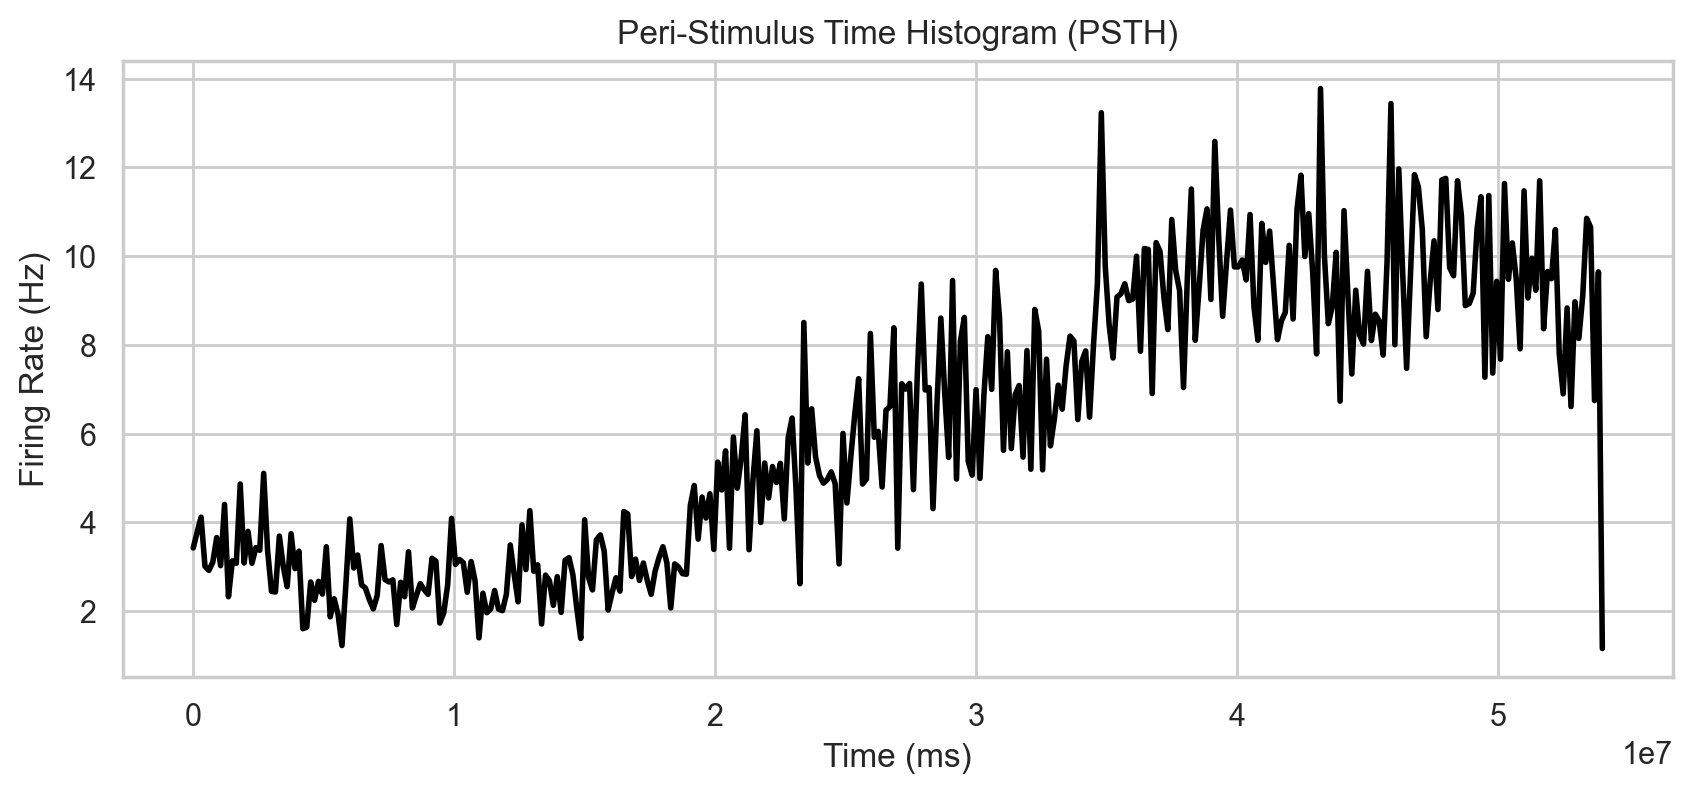

In [10]:
# Generate time points for the PSTH plot
psth_time = np.arange(num_bins) * bin_size

# Plot the PSTH
plt.figure(figsize=(10, 4))
plt.plot(psth_time, psth_rate, color='black', linewidth=2)
plt.title('Peri-Stimulus Time Histogram (PSTH)')
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')
plt.grid(True)
plt.show()

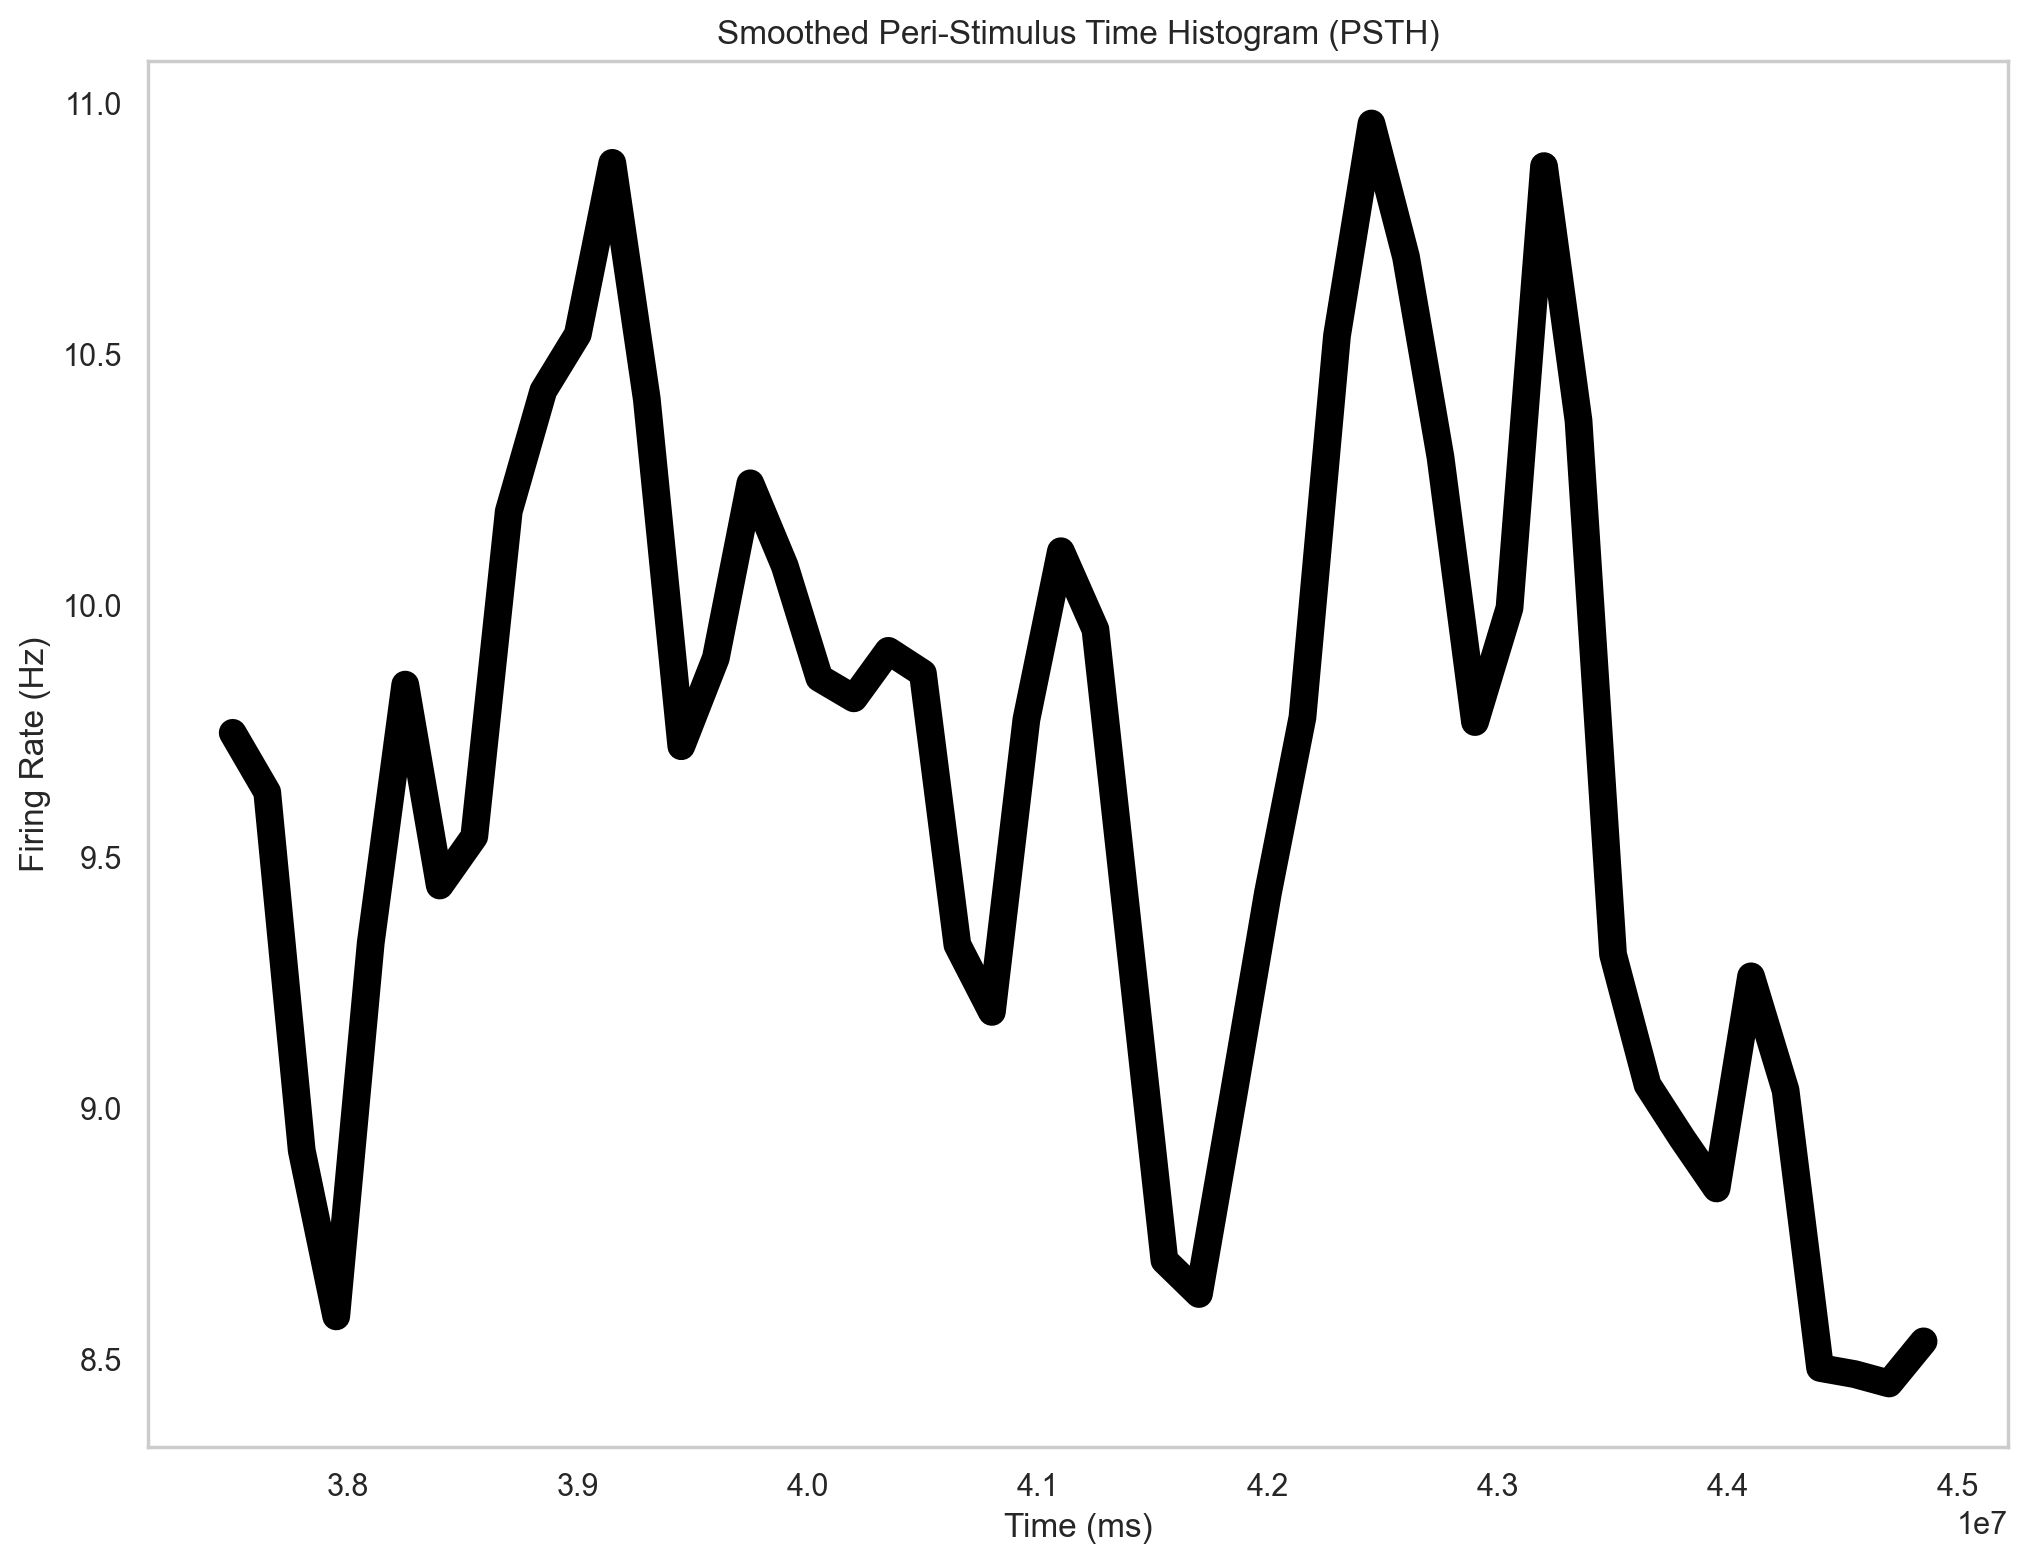

In [11]:
from scipy.ndimage import gaussian_filter1d

# Apply a Gaussian filter for smoothing
psth_rate_smoothed = gaussian_filter1d(psth_rate, sigma=1)

# Plot the smoothed PSTH

plt.plot(psth_time[250:300], psth_rate_smoothed[250:300], color='black', linewidth=10)
plt.title('Smoothed Peri-Stimulus Time Histogram (PSTH)')
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')

plt.show()

#### Temporal code figure 

#### Population code figure

### Part 2: Toy parameterization example - pvc6 

In [12]:
# open and load the data

fs = 200000 # sampling rate
one_ms = int(fs / 1000)

total_sweeps = 66

filename = '/Users/blancamartin/Downloads/153098.04.02_data.h5' # filename

# open file
f = h5py.File(filename, 'r')



In [13]:
# helper functions

# load sweeps
def load_sweep(sweep_number):
    # load sweep
    dset = f['Sweep_' + str(sweep_number)]

    # create array of time indices
    convert_to_ms = (fs / 1000)
    times = np.arange(0, np.shape(dset)[0]) / convert_to_ms # in ms instead of sec

    return dset, times



# find the spike times
def find_spike_times(data, thresh_mv, thresh_ms):
    # thresh_mv is the voltage threshold that needs to be crossed
    # thresh_ms is how many ms each peak needs to be from the next

    peaks = find_peaks(data, height=thresh_mv, distance=thresh_ms)
    idx_spikes = peaks[0] # spike indices
    amp_spikes = peaks[1]['peak_heights'] # spike amplitudes

    return idx_spikes, amp_spikes



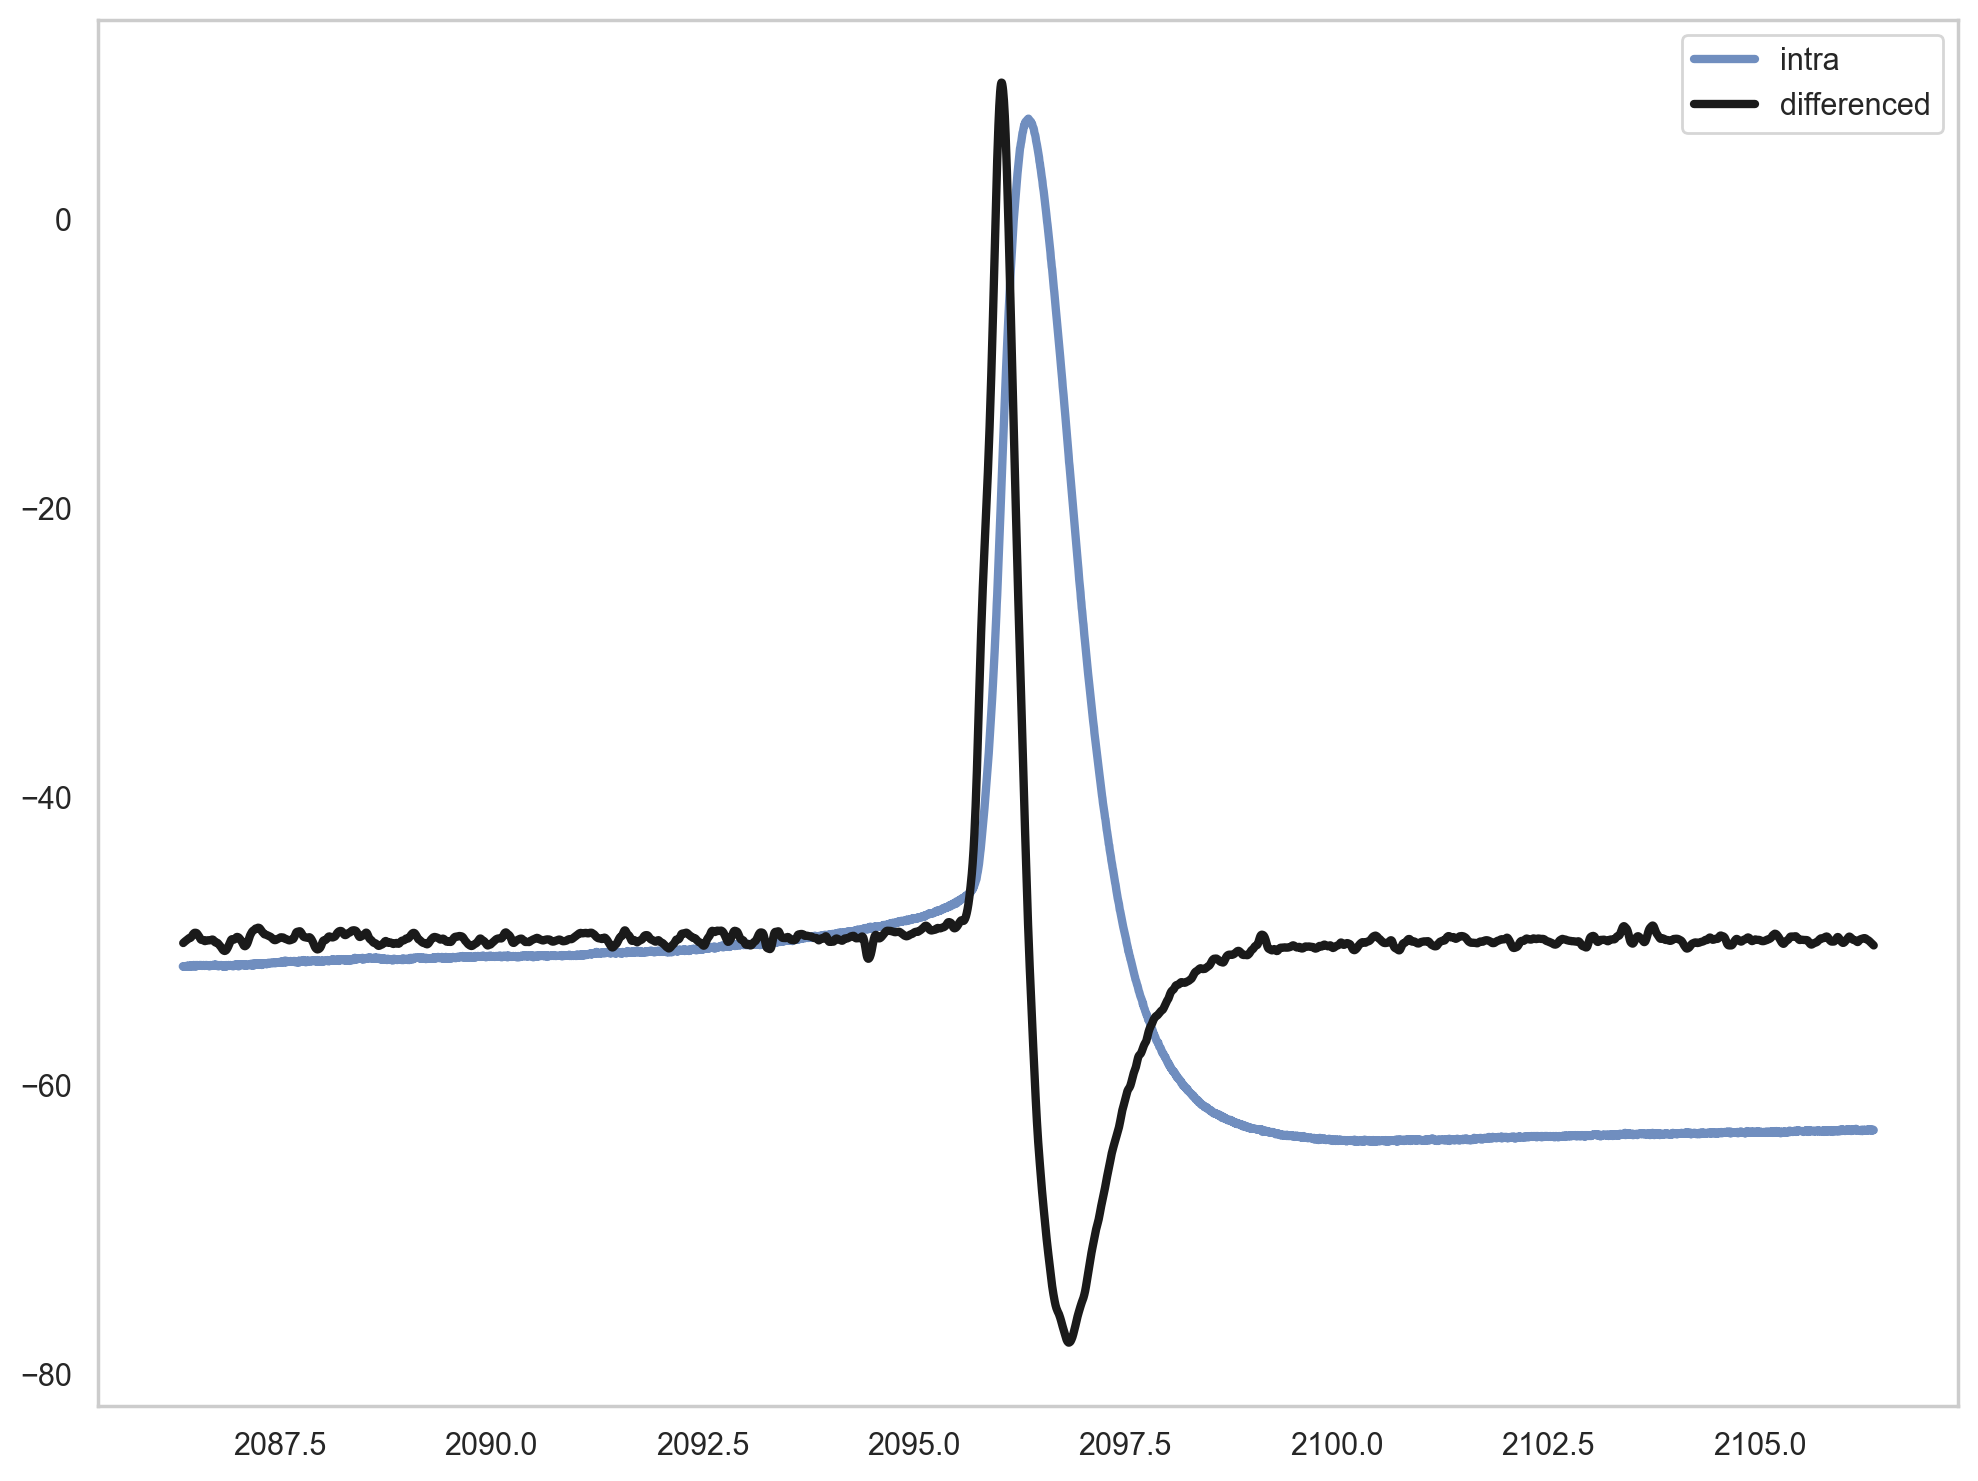

In [14]:
# Plot single spike, and its derivative
i_sweeps = 28
dset, times = load_sweep(i_sweeps)

stim = dset[:, 0] # current injection
data = dset[:, 1] # ephys data

#########################
# find spikes
thresh_mv = -10
thresh_ms = one_ms * 1 # 1 ms

idx_spikes, amp_spikes = find_spike_times(data, thresh_mv, thresh_ms)

#########################
i_spikes = 0
    
# get windows around spikes
# create window indices
window_length = (10, 10) # in ms
window_pre = int(one_ms * window_length[0])
window_post = int(one_ms * window_length[1])

# get window
window_spike_pre = (idx_spikes[i_spikes]-window_pre)
window_spike_post = (idx_spikes[i_spikes]+window_post)

# get window for times as well
windowed_times = times[(idx_spikes[i_spikes]-window_pre):
                    (idx_spikes[i_spikes]+window_post)]

# get data window
windowed_data = data[window_spike_pre:window_spike_post]

# difference of data, and smooth it
d_windowed_data = np.diff(windowed_data)
smoothed_data = sm.nonparametric.lowess(d_windowed_data, windowed_times[1:], frac=0.008)

# smoothed data
d_smoothed_times = smoothed_data[:, 0]
d_smoothed_data = smoothed_data[:, 1]

plt.plot(windowed_times, windowed_data, 'b', alpha = 0.8, linewidth = 3., label='intra')
plt.plot(d_smoothed_times, (d_smoothed_data*80)-50, 'k', linewidth = 3., label='differenced')
plt.legend()
plt.show()

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_2457/3251282466.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2980392156862745, 0.4470588235294118, 0.6901960784313725, 1)). The keyword argument will take precedence.
  plt.plot(windowed_times, windowed_data, 'b', alpha = 0.8, linewidth = 10.,color='k')


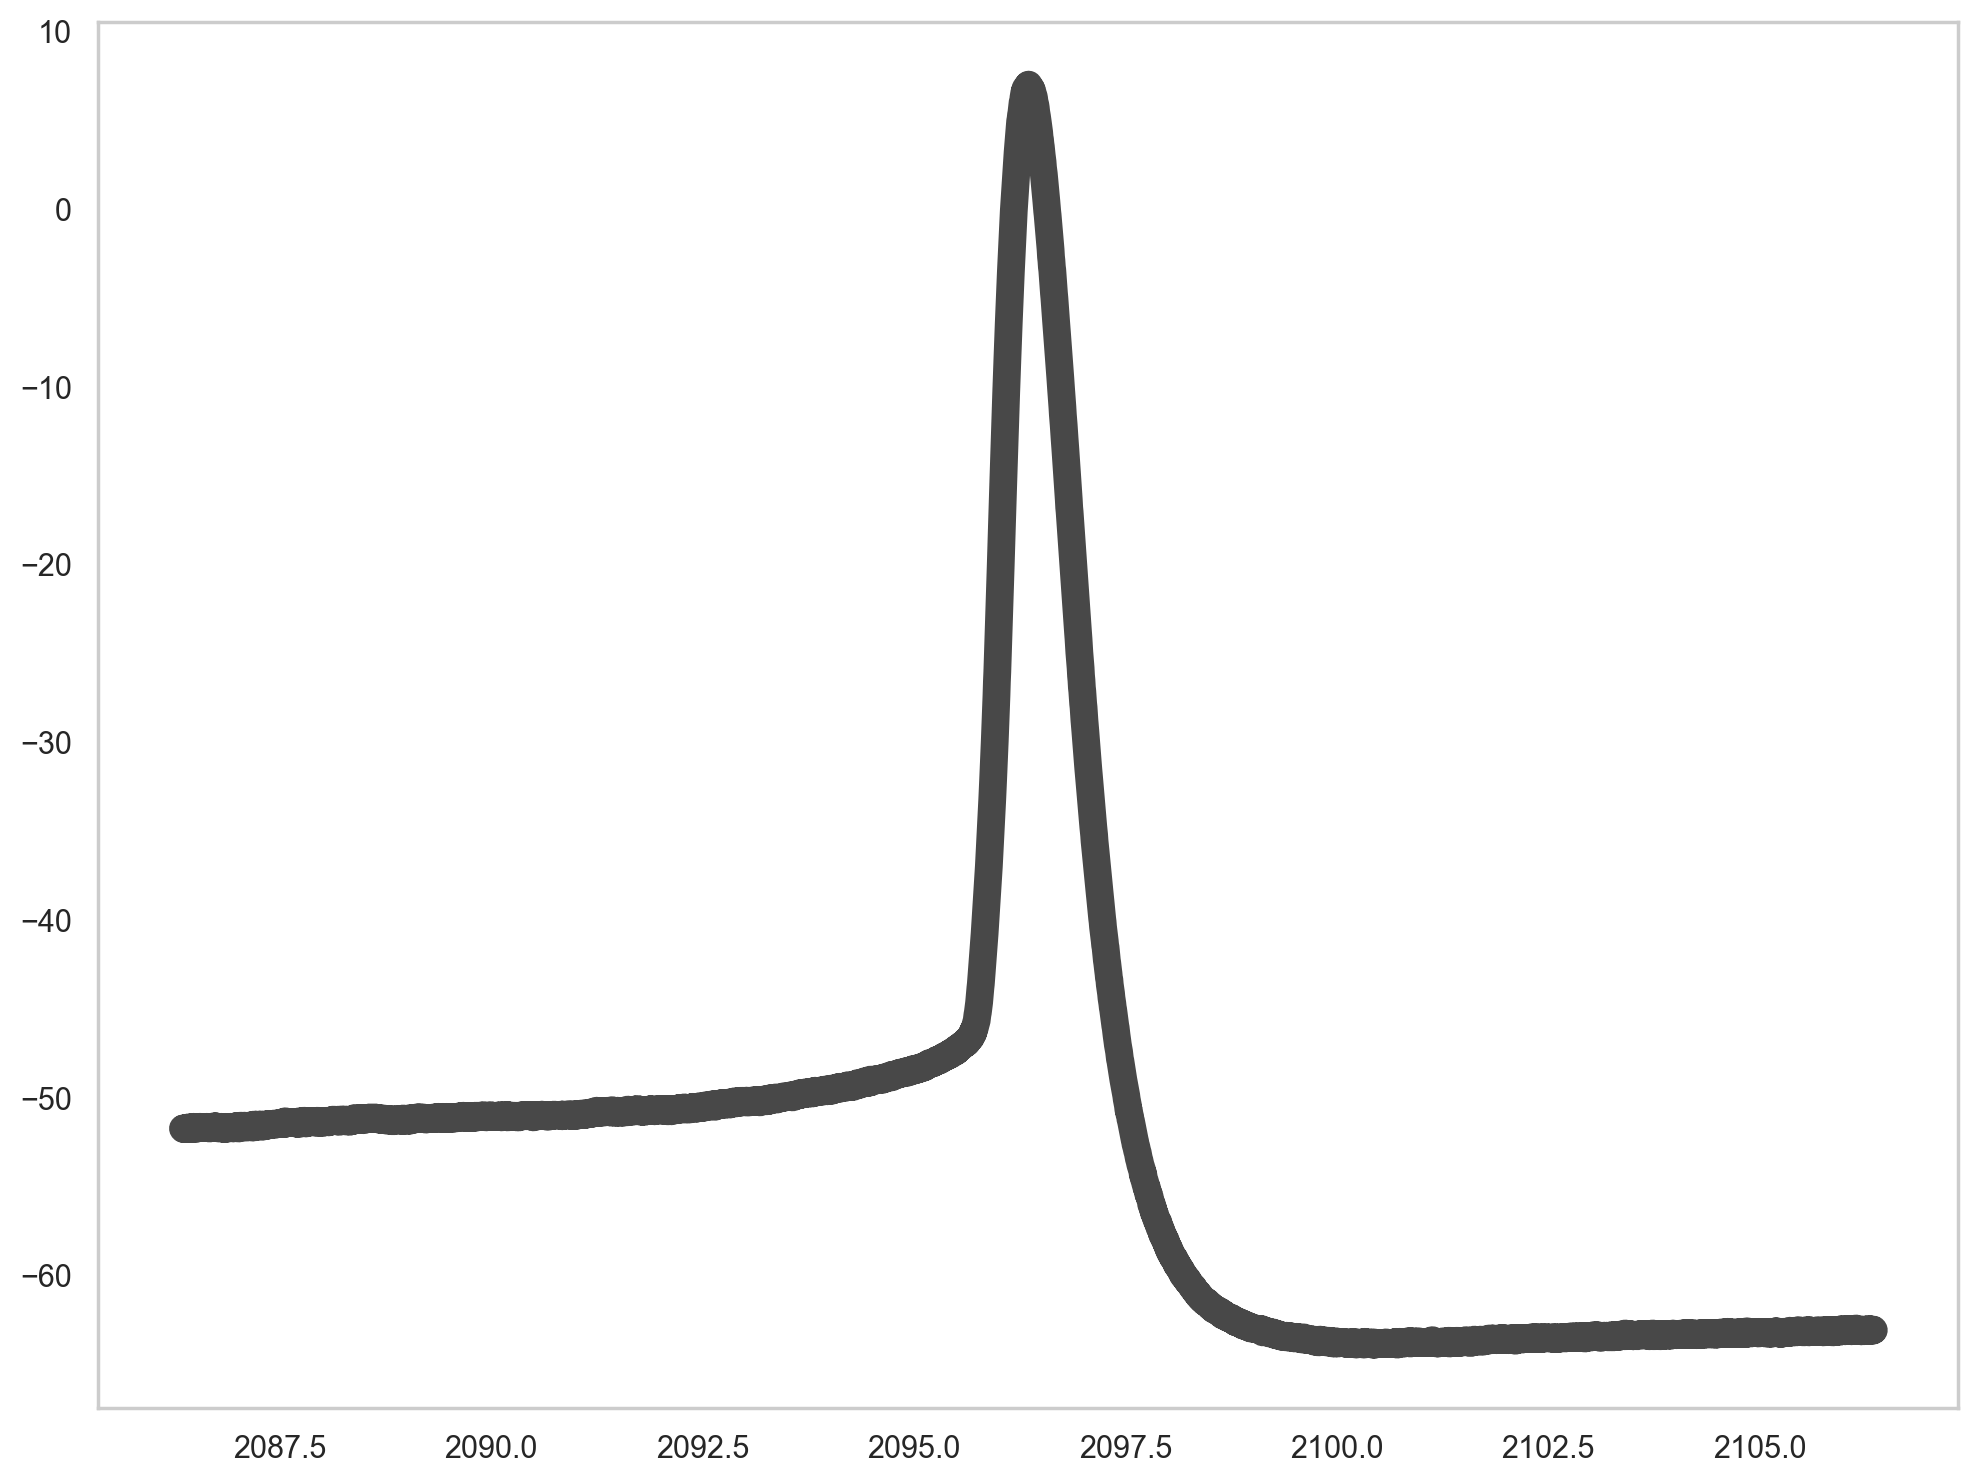

In [15]:
plt.plot(windowed_times, windowed_data, 'b', alpha = 0.8, linewidth = 10.,color='k')

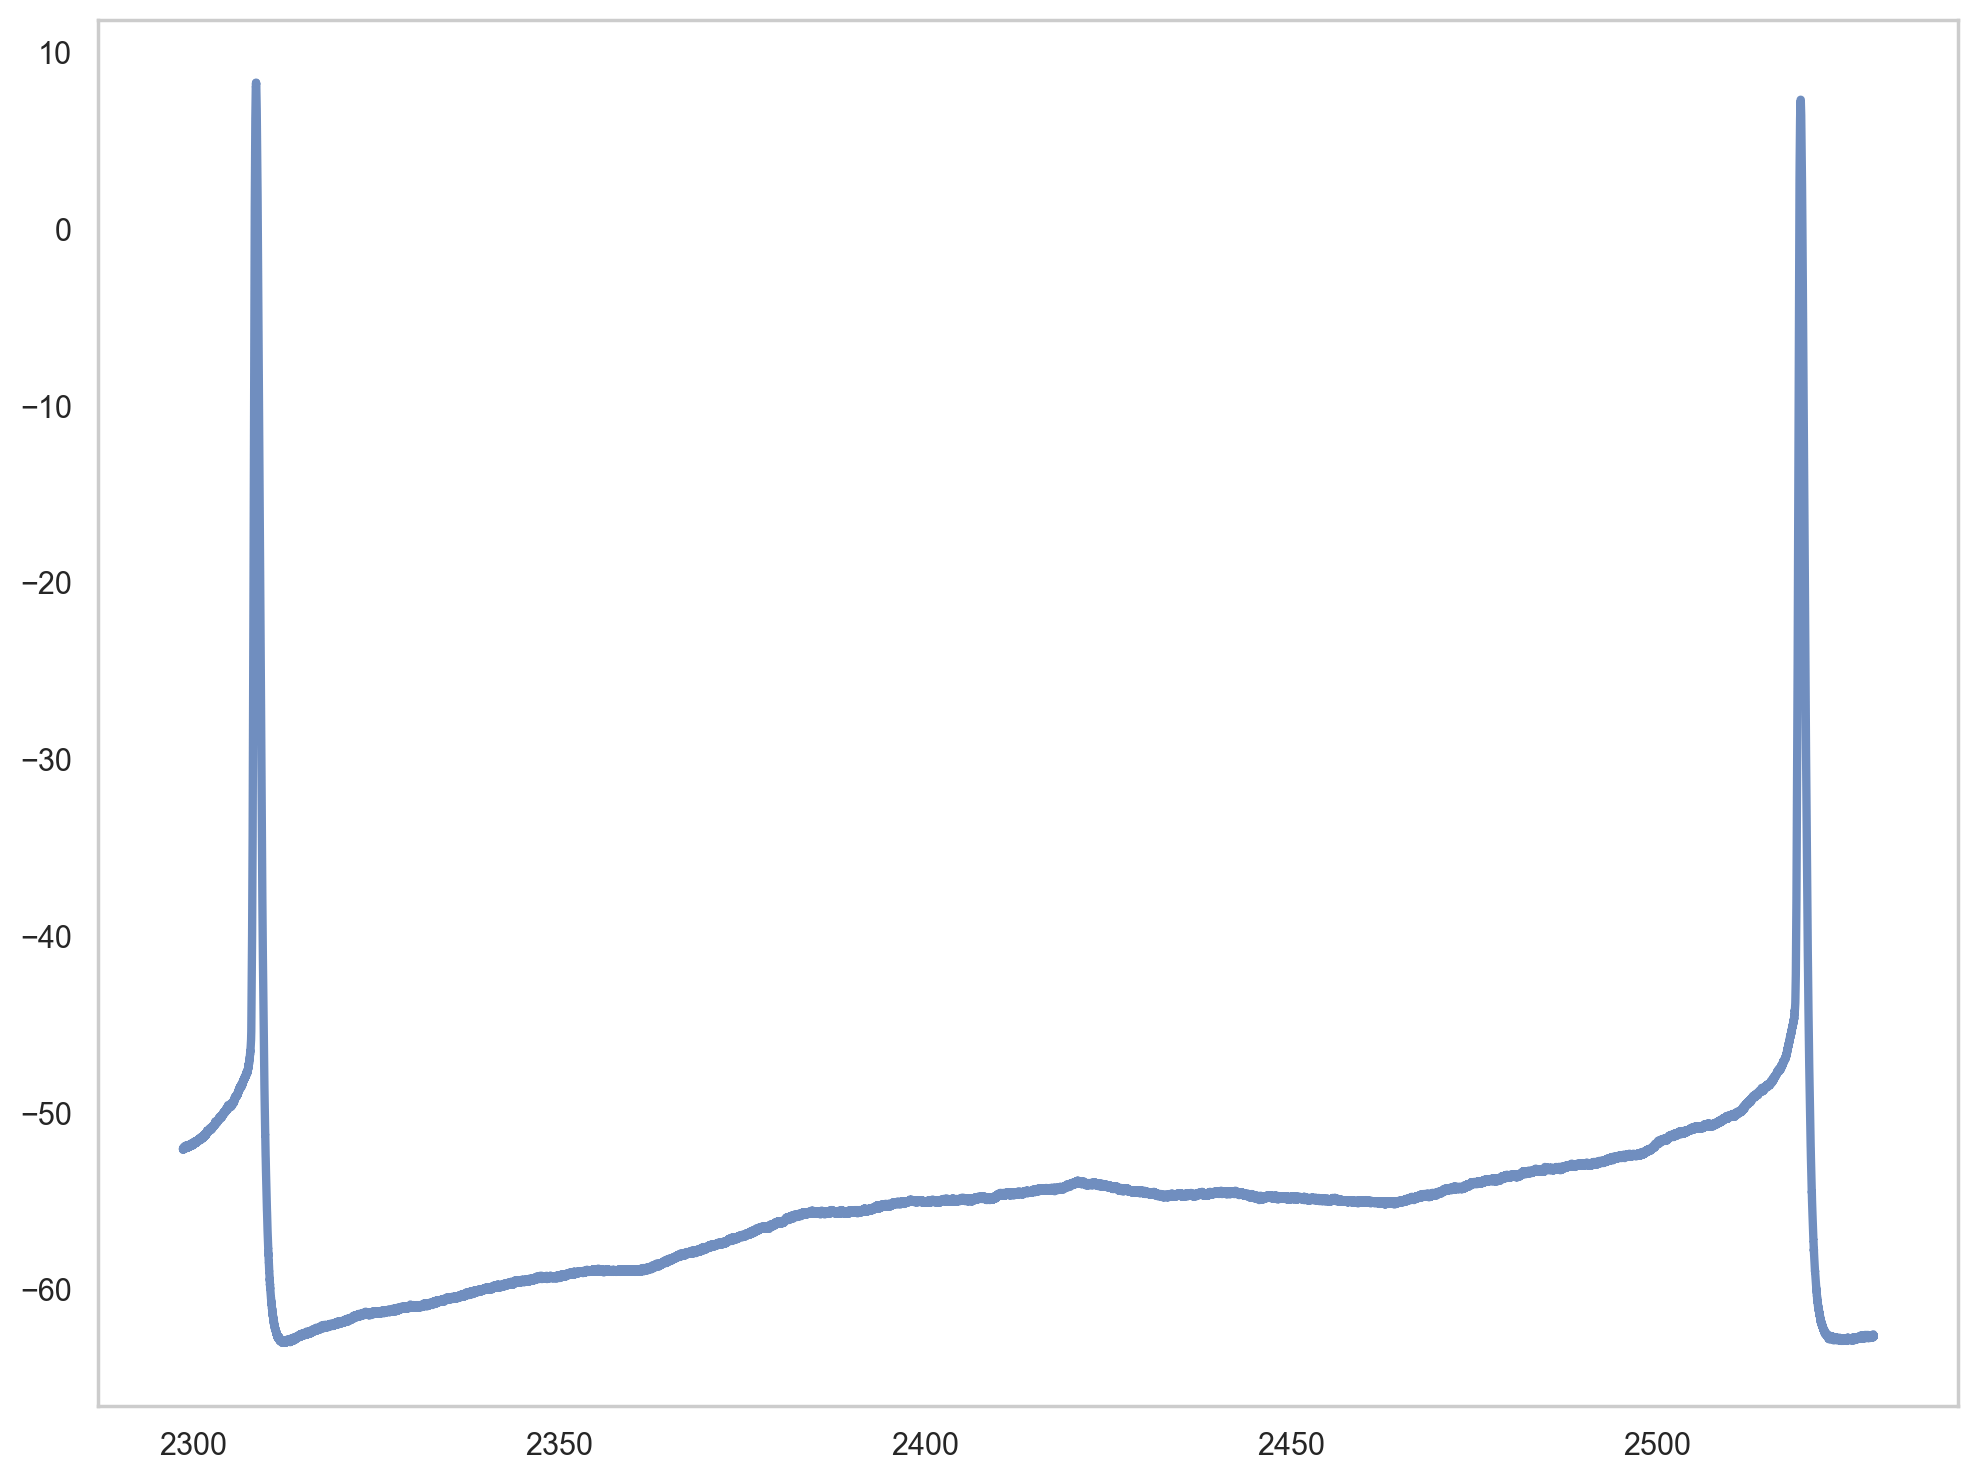

In [16]:
# Plot single spike, and its derivative

dset, times = load_sweep(14)

stim = dset[:, 0] # current injection
data = dset[:, 1] # ephys data



#########################
# find spikes
thresh_mv = -10
thresh_ms = one_ms * 1 # 1 ms

idx_spikes, amp_spikes = find_spike_times(data, thresh_mv, thresh_ms)



#########################
i_spikes = 1
    
# get windows around spikes
# create window indices
window_length = (10, 10) # in ms
window_pre = int(one_ms * window_length[0])
window_post = int(one_ms * window_length[1])

# get window
window_spike_pre = (idx_spikes[i_spikes]-window_pre)
window_spike_post = (idx_spikes[2]+window_post)

# get window for times as well
windowed_times = times[(idx_spikes[i_spikes]-window_pre):
                    (idx_spikes[2]+window_post)]

# get data window
windowed_data = data[window_spike_pre:window_spike_post]

# difference of data, and smooth it
d_windowed_data = np.diff(windowed_data)

toy_data = windowed_data
toy_times = windowed_times

plt.plot(toy_times, toy_data, 'b', alpha = 0.8, linewidth = 3., label='intra')



plt.show()

In [17]:
#recreate parameterization using the Spike class
#Run spikeparam on real EAPs 
sp_toy = Spike(thresh_amp=-10, window_length=(10, 10), smooth_frac=.01, )




sp_toy.fit(toy_data, fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/2 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


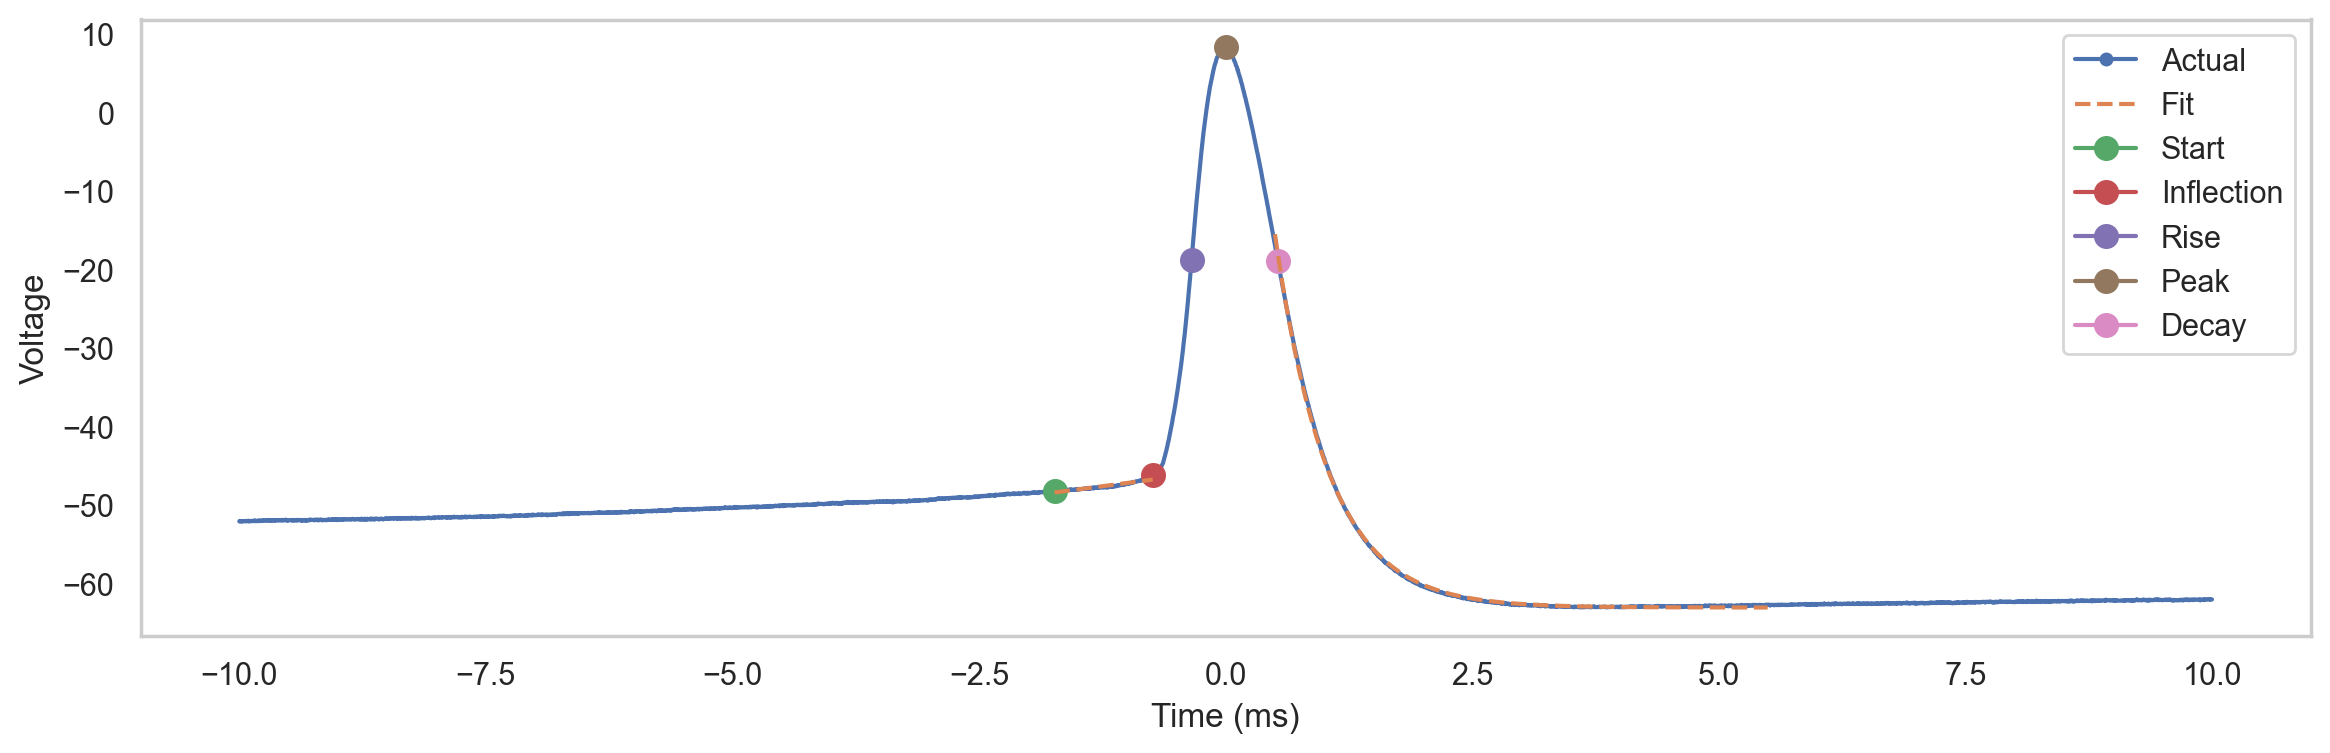

In [18]:
sp_toy.plot(show_points=True, inds=0)

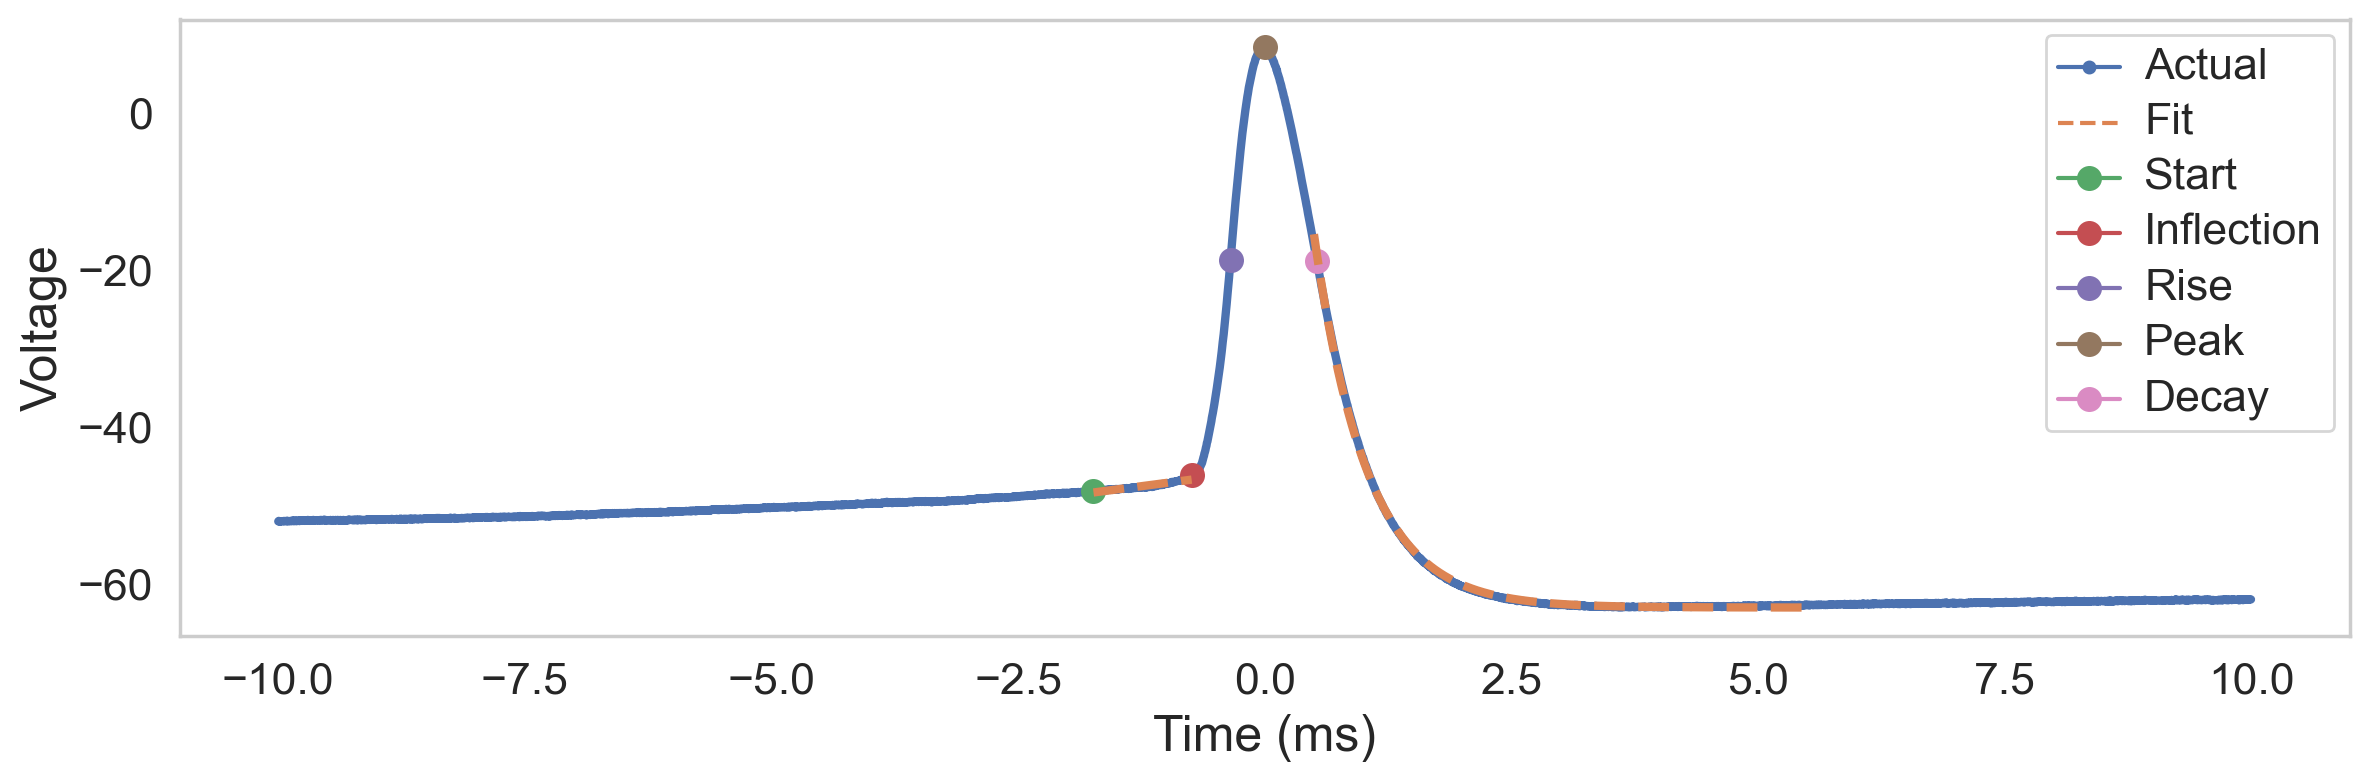

In [25]:
# First, plot using your class's plot function
sp_toy.plot(show_points=True, inds=0)

# After plotting, get the current figure and axis
fig = plt.gcf()  # Get the current figure
ax = plt.gca()   # Get the current axis

# Modify the font size of the labels
ax.set_xlabel('Time (ms)', fontsize=18)
ax.set_ylabel('Voltage', fontsize=18)

# Modify the font size of the legend
legend = ax.get_legend()
if legend:
    plt.setp(legend.get_texts(), fontsize=16)
# Modify the font size of the tick numbers
ax.tick_params(axis='both', which='major', labelsize=16)  # Adjust tick label size for both axes


# Modify line thickness
for line in ax.get_lines():
    line.set_linewidth(3)

# Finally, re-display the updated plot
plt.show()

In [19]:
sp_toy.df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
0,1.645808,0.735,-46.281251,8.28125,0.875,1.96875,1.862159,-63.032804,211.04,0.906929,0.999571
1,2.057672,0.770,-44.187501,7.31250,0.910,1.71875,1.696215,-62.864505,NaN,0.989322,0.999630


### Part 3: spikeparam applied to dataset + correlation - spe1-rh 

In [22]:
#threshold in mVs
sp = Spike(thresh_amp=100, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt_c14, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp.fit(patch_filt_c14, patch_fs_c14, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/4504 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


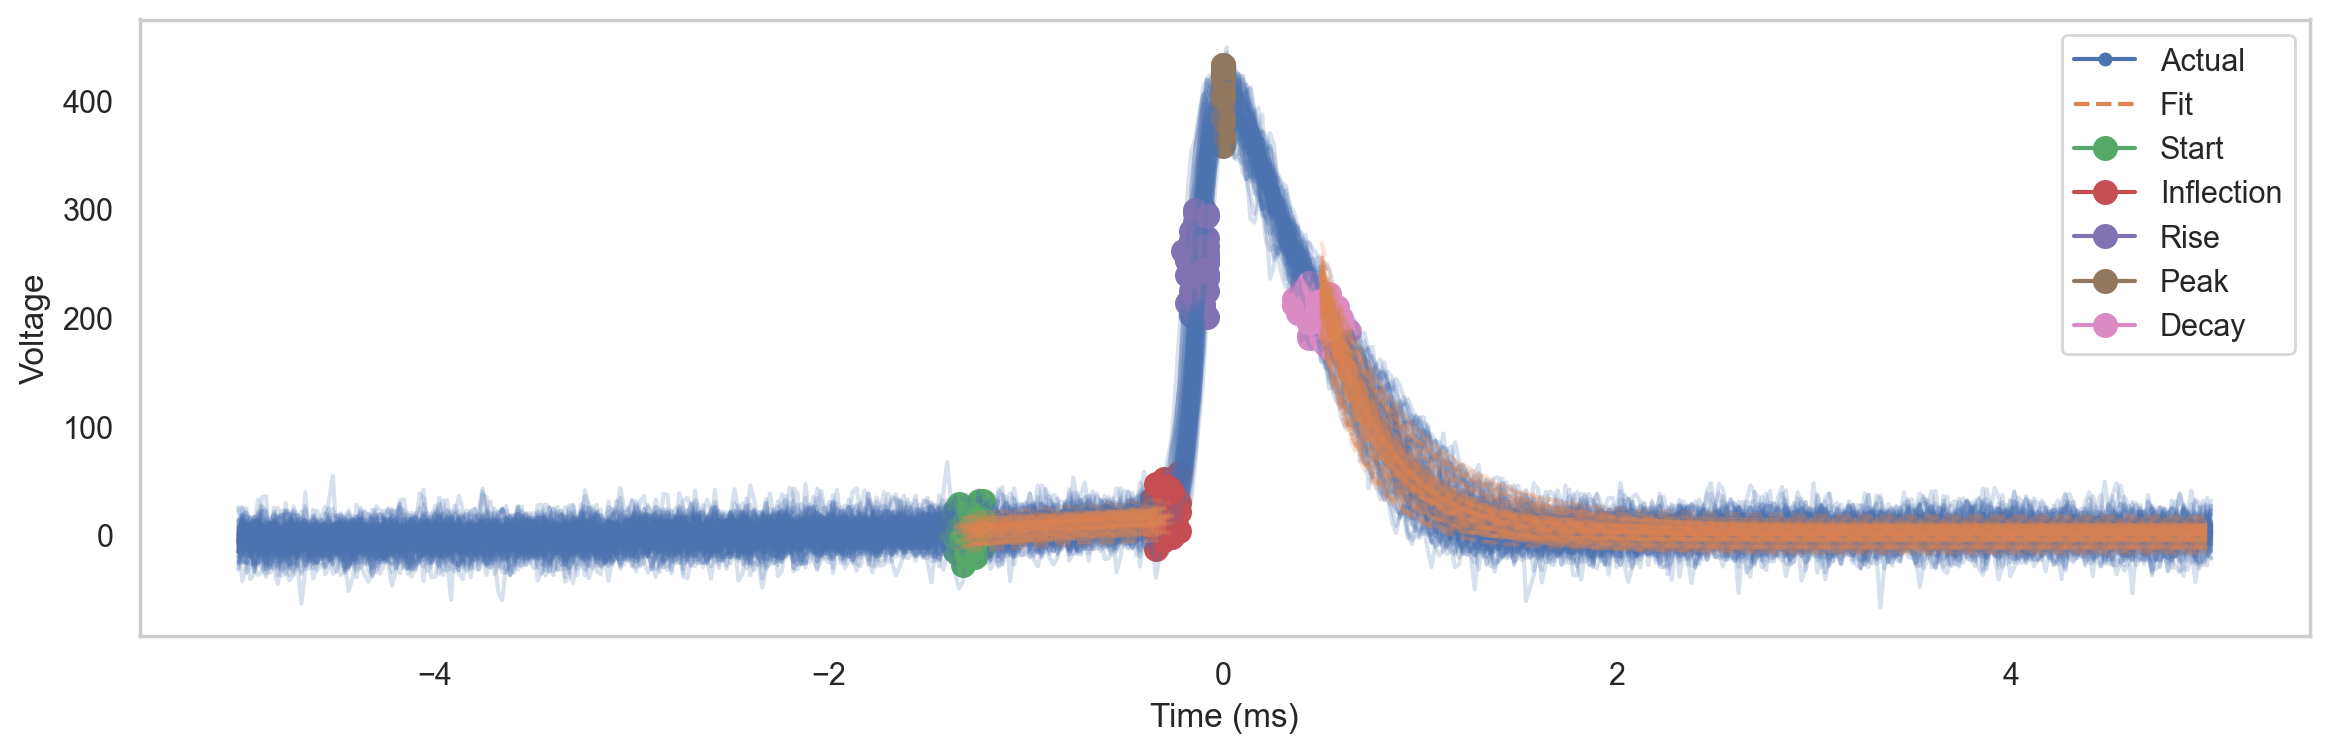

In [23]:
# First 100 fits
sp.plot(inds=np.arange(
    100), mode='full', show_points=True)

In [25]:
df_features = sp.df_features
# Add an index column to df_features to maintain original indices
df_features['original_index'] = df_features.index

In [26]:
# Ensure inflection times are between 0 and 2 ms
df_features  = df_features .loc[df_features['inflection_time'] > 0.]
df_features = df_features .loc[df_features['inflection_time'] < 2.]
# Remove low r-squares (ramping fits are especially noisy)
df_features = df_features.loc[df_features['r_squared_exp']  >= .5]
df_features = df_features.loc[df_features['r_squared_ramp'] >= .1]
# log10 ISIs
df_features[['isi']] = np.log10(df_features[['isi']])
df_features.rename(columns={'isi':'log_isi'}, inplace=True)
# drop no-longer-used QC features
df_features = df_features.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_features = df_features.replace([np.inf, -np.inf], np.nan)



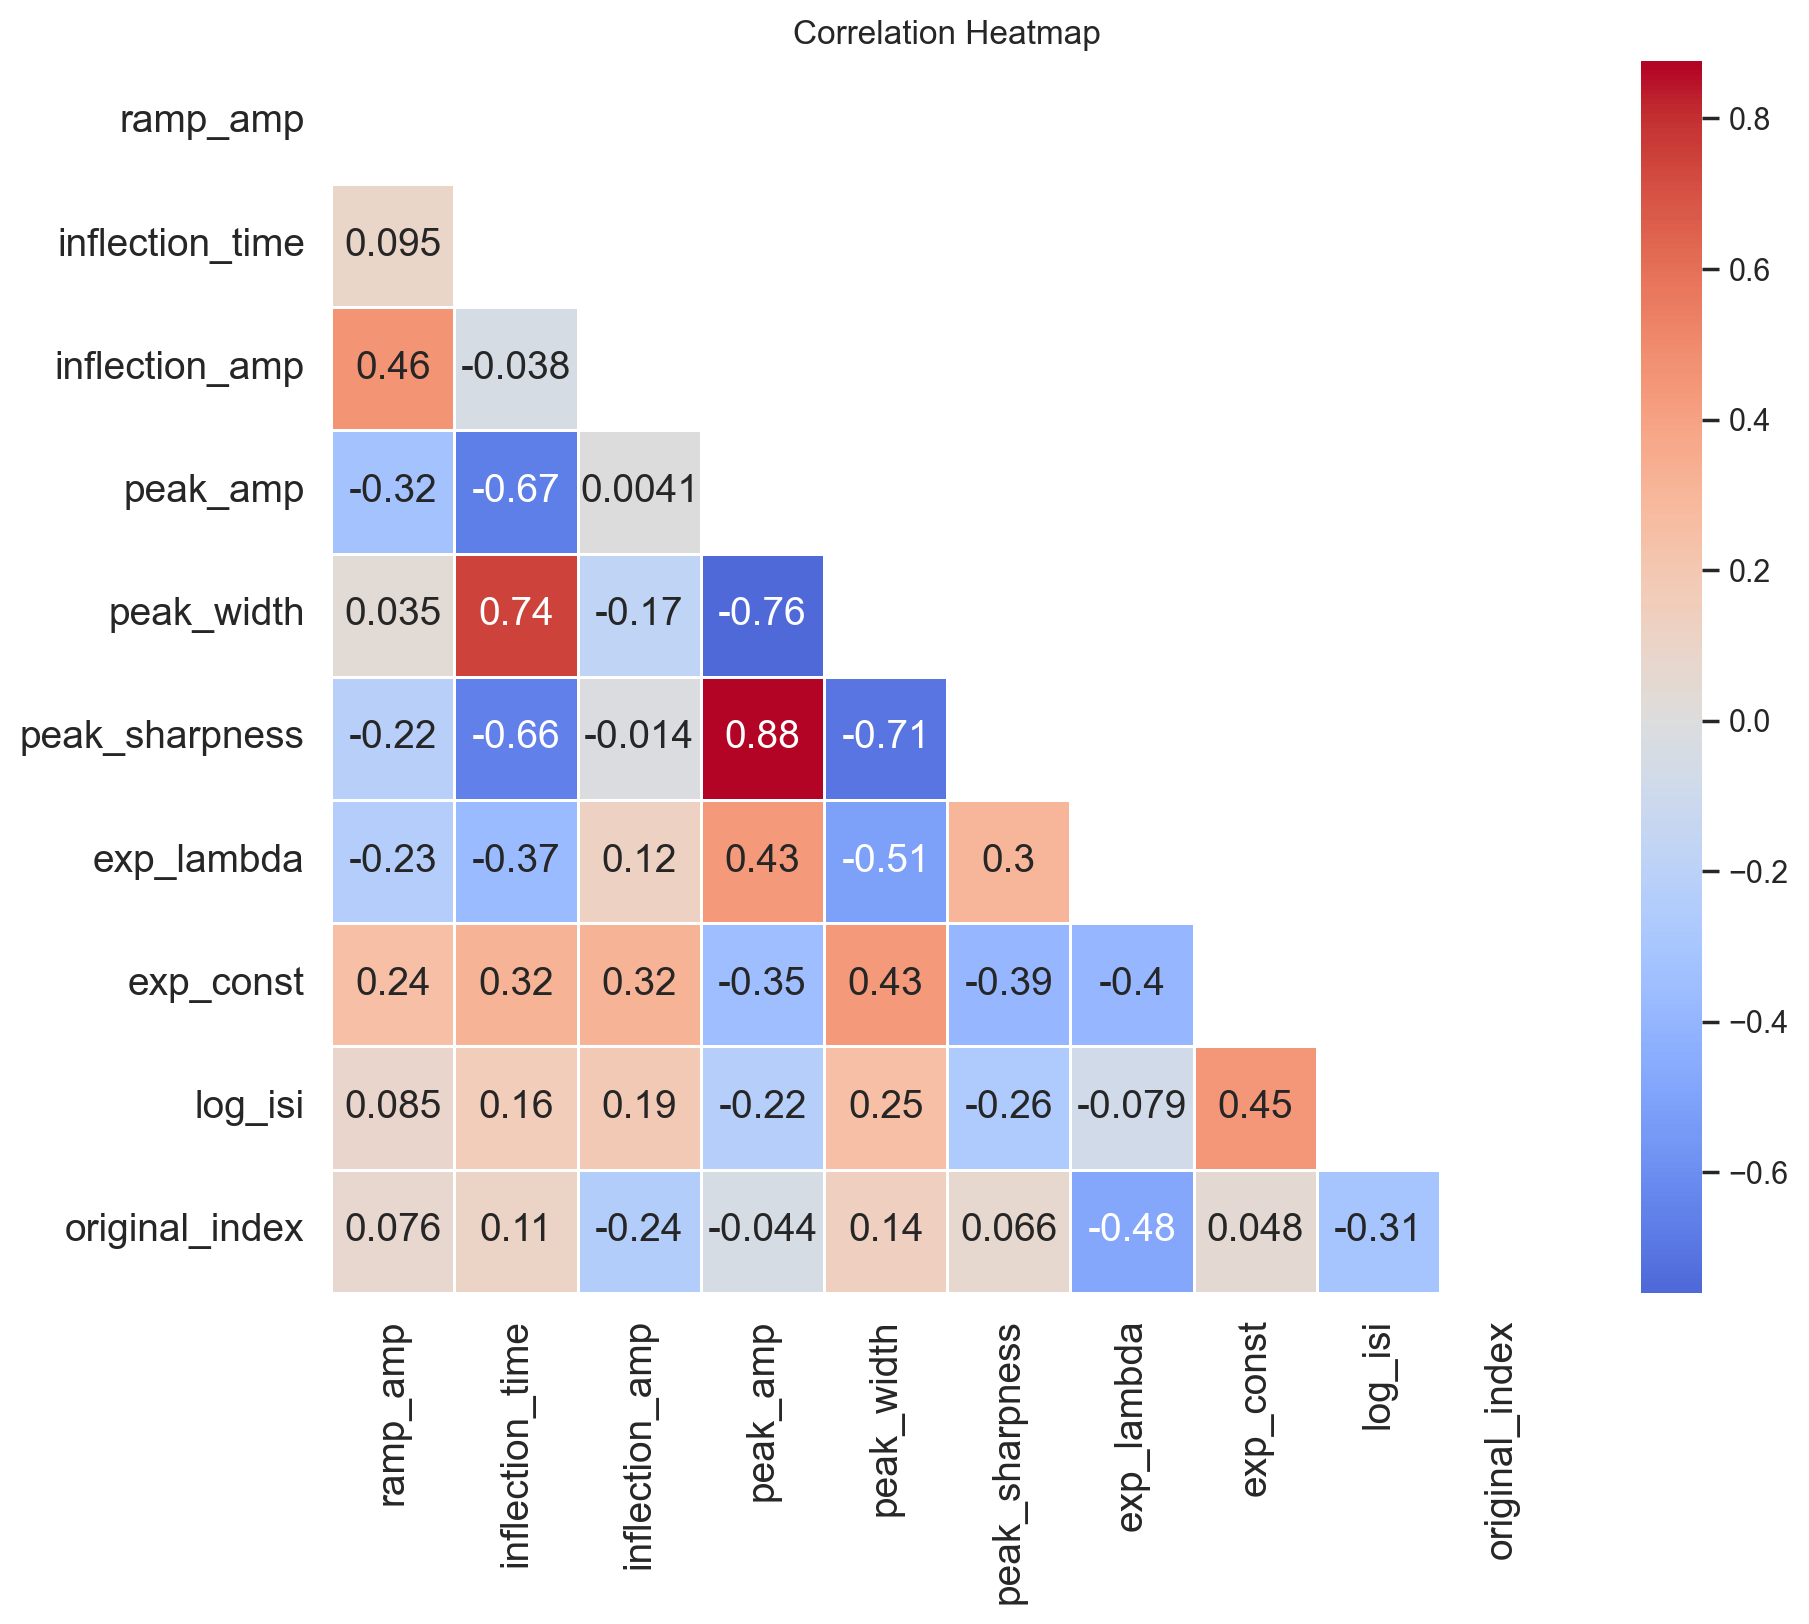

In [27]:
# Calculate correlation matrix and p-values
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval < 0.05  # Create a mask for significant p-values

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(rho, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(rho, mask=mask, cmap='coolwarm', annot=True, fmt='.2', linewidths=0.5, center=0, square=True,  annot_kws={"size": 14})
# Increase fontsize of tick labels on both axes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title('Correlation Heatmap')
plt.show()
